# Model Evaluation

In [1]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from tensorflow.keras.models import load_model
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import numpy as np
import os
sns.set_theme(style="darkgrid", context="paper", palette="bright")

2026-03-11 21:57:01.050804: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-11 21:57:01.088694: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-11 21:57:02.167593: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
PROJECT_ROOT = os.path.abspath("..")
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
MODEL_DIR = os.path.join(PROJECT_ROOT, "models")
ARTIFACT_DIR = os.path.join(PROJECT_ROOT, "artifacts")

In [3]:
model = load_model(os.path.join(MODEL_DIR, "model.keras"))
history = pd.read_csv(os.path.join(MODEL_DIR, "history.csv"))

X_test_scaled = np.load(os.path.join(ARTIFACT_DIR, "X_test.npy"))
y_test = np.load(os.path.join(ARTIFACT_DIR, "y_test.npy"))
encoder = joblib.load(os.path.join(ARTIFACT_DIR, "encoder.pkl"))

2026-03-11 21:57:02.738649: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    fig, ax = plt.subplots(1, 2, figsize=(20, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax[0],
        xticklabels=classes,
        yticklabels=classes,
    )
    ax[0].set_title("Confusion Matrix (Counts)")
    ax[0].set_ylabel("True Label")
    ax[0].set_xlabel("Predicted Label")

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Greens",
        ax=ax[1],
        xticklabels=classes,
        yticklabels=classes,
    )
    ax[1].set_title("Confusion Matrix (Normalized)")
    ax[1].set_ylabel("True Label")
    ax[1].set_xlabel("Predicted Label")

    plt.tight_layout()
    plt.show()

In [5]:
y_pred_probs = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

27367/27367 ━━━━━━━━━━━━━━━━━━━━ 19s 681us/step


[[ 22614      0      0    168    252]
 [     4 464406 120247      5      1]
 [     1  80163 142047      8      2]
 [   235      1      4  32409     16]
 [   513      0      1      9  12617]]


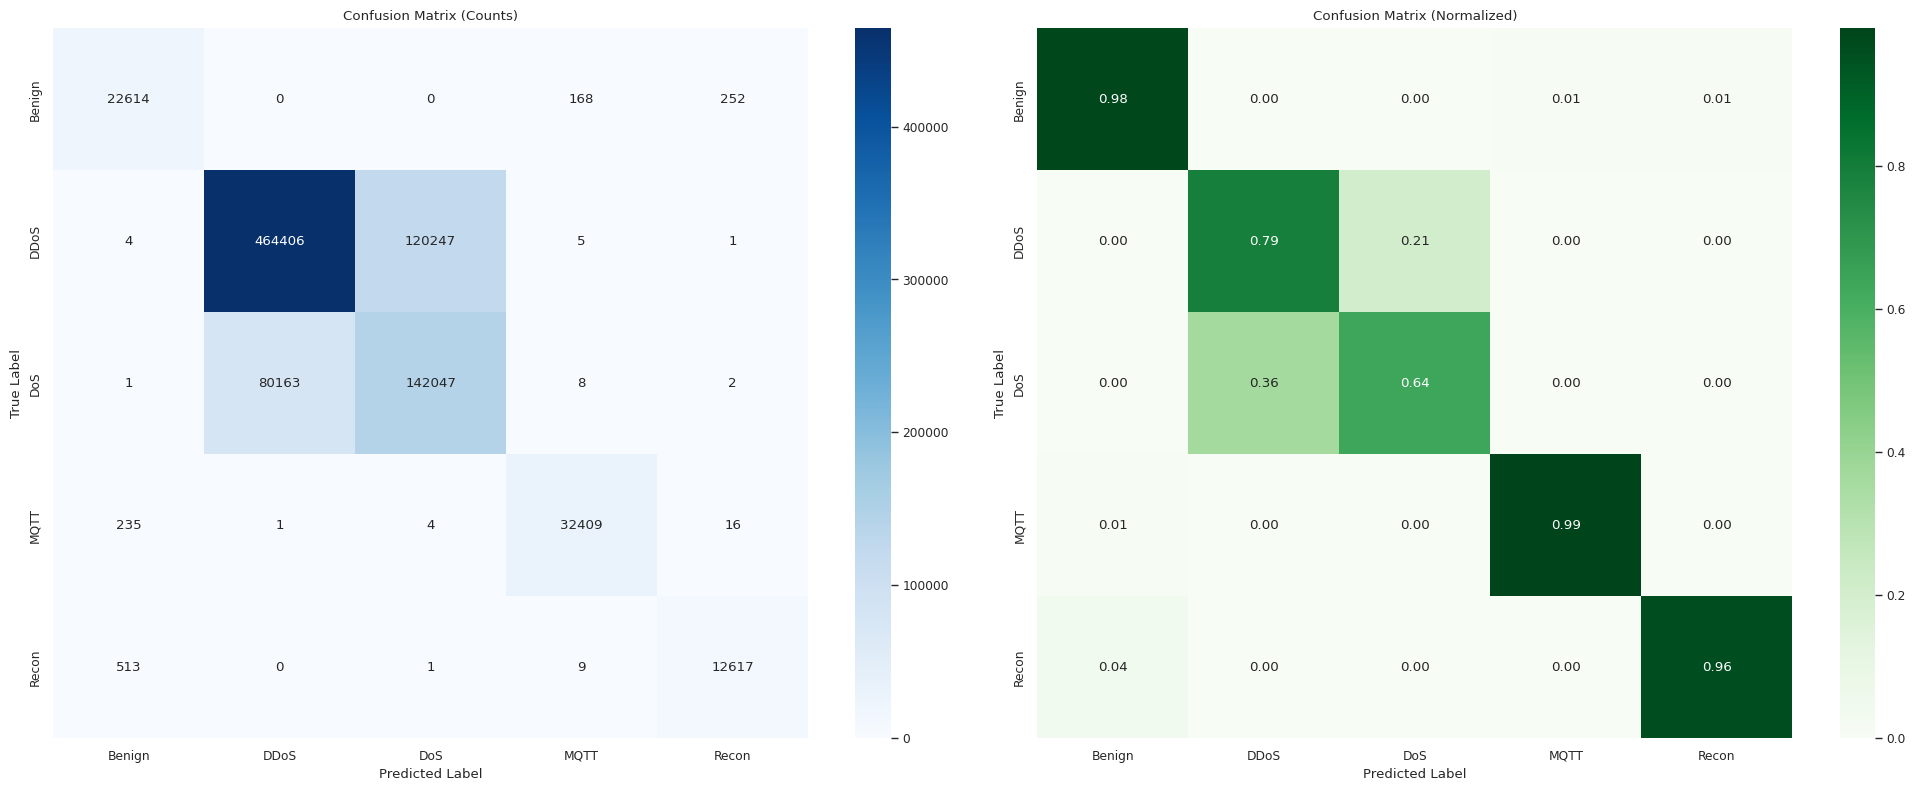

In [6]:
plot_confusion_matrix(y_test, y_pred_classes, encoder.classes_)

In [7]:
print(
    classification_report(
        y_test, y_pred_classes, digits=4, target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

      Benign     0.9678    0.9818    0.9747     23034
        DDoS     0.8528    0.7943    0.8225    584663
         DoS     0.5415    0.6392    0.5863    222221
        MQTT     0.9942    0.9922    0.9932     32665
       Recon     0.9790    0.9602    0.9695     13140

    accuracy                         0.7698    875723
   macro avg     0.8671    0.8735    0.8692    875723
weighted avg     0.7840    0.7698    0.7752    875723



In [8]:
f1_score(y_test, y_pred_classes, average="macro")

0.8692475830425588

In [9]:
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test accuracy: {accuracy:.4f}")

27367/27367 ━━━━━━━━━━━━━━━━━━━━ 22s 808us/step - accuracy: 0.7698 - loss: 0.4796
Test accuracy: 0.7698
